# <center>Блок 6. Математика в ML. Часть II<center>
## <center>MATH&ML-9. Математика ансамблевых методов<center>
### <center>1.Введение<center>
### <center>2.Ансамбли моделей. Бустреппинг. Бэггинг<center>
#### <center>Bias и Variance<center>
#### <center>Бэггинг<center>

In [75]:
import pandas as pd
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn import tree, metrics
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import BaggingClassifier, RandomForestRegressor, RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from catboost import Pool, utils
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
data = pd.read_csv('C:\\IDE\\data\\Block_6\\wineQualityReds.csv')
data.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 6 else 0)

In [4]:
X = data.drop('quality', axis=1)
y = data['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

In [5]:
# Задание 2.7

lg_model = LogisticRegression(random_state=42)
lg_model.fit(X_train, y_train)
dt_model = tree.DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

y_log_pred = lg_model.predict(X_test)
y_tree_pred = dt_model.predict(X_test)

print('F1-score для логистической регресии: ', round(metrics.f1_score(y_test, y_log_pred),3))
print('F1-score для дерева решений: ', round(metrics.f1_score(y_test, y_tree_pred),3))

F1-score для логистической регресии:  0.739
F1-score для дерева решений:  0.76


c:\Users\Smoking Shop\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
# Задание 2.8
bg_model = BaggingClassifier(
    estimator=dt_model,
    n_estimators=1500,
    random_state=42
)
bg_model.fit(X_train, y_train)

y_bg_pred = bg_model.predict(X_test)
print('F1-score для бэггинга: ', round(metrics.f1_score(y_test, y_bg_pred),3))

F1-score для бэггинга:  0.824


### <center>3.Случайный лес<center>

In [7]:
boston_data = pd.read_csv('C:\\IDE\\data\\Block_6\\boston (1).csv')
boston_data.head()

,crim_rate,zn,business,river,nit_oxiden,rooms,age,dist,highways_index,tax,pup_per_teaс,lower,target
0,"0,00632",18,"2,31",0,"0,538","6,575","65,2","4,09",1,296,"15,3","4,98",24
1,"0,02731",0,"7,07",0,"0,469","6,421","78,9","4,9671",2,242,"17,8","9,14","21,6"
2,"0,02729",0,"7,07",0,"0,469","7,185","61,1","4,9671",2,242,"17,8","4,03","34,7"
3,"0,03237",0,"2,18",0,"0,458","6,998","45,8","6,0622",3,222,"18,7","2,94","33,4"
4,"0,06905",0,"2,18",0,"0,458","7,147","54,2","6,0622",3,222,"18,7","5,33","36,2"


In [8]:
boston_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   crim_rate       506 non-null    object
 1   zn              506 non-null    object
 2   business        506 non-null    object
 3   river           506 non-null    int64 
 4   nit_oxiden      506 non-null    object
 5   rooms           506 non-null    object
 6   age             506 non-null    object
 7   dist            506 non-null    object
 8   highways_index  506 non-null    int64 
 9   tax             506 non-null    int64 
 10  pup_per_teaс    506 non-null    object
 11  lower           506 non-null    object
 12  target          506 non-null    object
dtypes: int64(3), object(10)
memory usage: 51.5+ KB


In [9]:
def convert_commas_to_dots(df, columns):
    """
    Заменяет запятые на точки и удаляет пробелы в указанных столбцах,
    после чего преобразует их в числовой тип (float).
    """
    
    for col in columns:
        if col in df.columns:
            # Удаляем пробелы (если есть) и меняем запятую на точку
            df[col] = (df[col]
                            .astype(str) # Принудительно приводим к строке на случай смешанных типов
                            .str.replace(',', '.', regex=False))
            
            # Преобразуем в числовой тип, превращая ошибки в NaN (например, если встретится текст)
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    return df

boston_data = convert_commas_to_dots(boston_data, boston_data.columns)

In [10]:
X = boston_data.drop('target', axis=1)
y = boston_data[['target']]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=13)

In [11]:
# Задание 3.4

print(y_train['target'].median())

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print('MAE на линейной регрессии: ', round(metrics.mean_absolute_error(y_test, lr_pred),2))

tree_model = tree.DecisionTreeRegressor(random_state=13)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
print('MAE на дереве решений: ', round(metrics.mean_absolute_error(y_test, tree_pred),2))

21.55
MAE на линейной регрессии:  3.72
MAE на дереве решений:  2.84


In [12]:
rf_model_3 = RandomForestRegressor(n_estimators=3, random_state=13)
rf_model_10 = RandomForestRegressor(n_estimators=10, random_state=13)
rf_model_100 = RandomForestRegressor(n_estimators=100, random_state=13)
rf_model_500 = RandomForestRegressor(n_estimators=500, random_state=13)

rf_model_3.fit(X_train, y_train)
rf_model_10.fit(X_train, y_train)
rf_model_100.fit(X_train, y_train)
rf_model_500.fit(X_train, y_train)

pred_3_model = rf_model_3.predict(X_test)
pred_10_model = rf_model_10.predict(X_test)
pred_100_model = rf_model_100.predict(X_test)
pred_500_model = rf_model_500.predict(X_test)

print('MAE на моделе с 3 деревьями: ', round(metrics.mean_absolute_error(y_test, pred_3_model),2))
print('MAE на моделе с 10 деревьями: ', round(metrics.mean_absolute_error(y_test, pred_10_model),2))
print('MAE на моделе с 100 деревьями: ', round(metrics.mean_absolute_error(y_test, pred_100_model),2))
print('MAE на моделе с 500 деревьями: ', round(metrics.mean_absolute_error(y_test, pred_500_model),2))

c:\Users\Smoking Shop\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Smoking Shop\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Smoking Shop\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Smoking Shop\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\b

MAE на моделе с 3 деревьями:  2.93
MAE на моделе с 10 деревьями:  2.47
MAE на моделе с 100 деревьями:  2.26
MAE на моделе с 500 деревьями:  2.24


### <center>4.Случайный лес. Практика<center>

In [13]:
rain_data = pd.read_csv('C:\\IDE\\data\\Block_6\\weatherAUS.csv')
rain_data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [14]:
# Задание 4.1

rain_data.isnull().sum().sum()

343248

In [15]:
# Задание 4.2

missing_percentage = rain_data.isnull().mean() * 100
print(missing_percentage)

rain_data = rain_data.drop(['Evaporation', 'Sunshine', 'Cloud3pm'], axis=1)

Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64


In [16]:
# Задание 4.3

rain_data['RainToday'] = rain_data['RainToday'].apply(lambda x: 1 if x == 'Yes' else 0)
rain_data['RainTomorrow'] = rain_data['RainTomorrow'].apply(lambda x: 1 if x == 'Yes' else 0)

print(round(rain_data['RainToday'].mean(),2))

0.22


In [17]:
# Задание 4.4

rain_data['Month'] = pd.to_datetime(rain_data['Date']).dt.month
rain_data = rain_data.drop('Date', axis=1)

rain_month = rain_data.groupby('Month')['RainToday'].sum()
print(rain_month)

Month
1     2447
2     2176
3     2831
4     2451
5     2901
6     3267
7     3189
8     2978
9     2600
10    2321
11    2415
12    2304
Name: RainToday, dtype: int64


In [18]:
# Задание 4.5

categoricals = ['Month', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

rain_data = pd.get_dummies(rain_data, columns=categoricals)

print(rain_data.columns)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm',
       ...
       'WindDir3pm_NNW', 'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE',
       'WindDir3pm_SSE', 'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W',
       'WindDir3pm_WNW', 'WindDir3pm_WSW'],
      dtype='object', length=124)


In [19]:
# Задание 4.6
rain_data_clean = rain_data.dropna()

X = rain_data_clean.drop('RainTomorrow', axis=1)
y = rain_data_clean['RainTomorrow']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=31)

print(round(y_test.mean(),2))

0.23


In [20]:
# Задание 4.7

# Фиксируем случайность
np.random.seed(31)

# Выделяем признак MinTemp, принудительно переводя в массив numpy
min_temp_values = rain_data['MinTemp'].to_numpy(dtype=float)

# ИСКЛЮЧАЕМ ПРОПУСКИ: оставляем только реальные числа
min_temp_values = min_temp_values[~np.isnan(min_temp_values)]


# Длина выборки
n = len(min_temp_values)

# Список для хранения средних значений каждой из 1000 выборок
bootstrap_means = []

# Генерируем 1000 бутстреп-выборок
for _ in range(1000):
    # Генерируем случайные индексы такого же объема с помощью np.random.randint
    indices = np.random.randint(0, n, size=n)
    
    # Извлекаем элементы по сгенерированным индексам
    sample = min_temp_values[indices]
    
    # Вычисляем среднее значение для текущей выборки и сохраняем
    bootstrap_means.append(sample.mean())

# Вычисляем стандартное отклонение полученных средних значений
std_of_means = np.std(bootstrap_means)

# Выводим ответ, округленный до двух знаков после запятой
print(f"Оценка стандартного отклонения для среднего значения: {std_of_means:.2f}")


Оценка стандартного отклонения для среднего значения: 0.02


In [21]:
# Задание 4.8

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print('Roc-auc score для линейной регрессии: ', round(metrics.roc_auc_score(y_test, y_pred),2))

Roc-auc score для линейной регрессии:  0.73


c:\Users\Smoking Shop\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
# Задание 4.9

params = {'max_leaf_nodes': list(range(2, 10)), 'min_samples_split': [2, 3, 4], 'max_depth': [5,7,9,11]}

grid_serch = GridSearchCV(tree.DecisionTreeClassifier(random_state=42), param_grid=params, cv=3)
grid_serch.fit(X_train, y_train)
grid_serch.predict(X_test)
print(grid_serch.best_params_)

dt_model = tree.DecisionTreeClassifier(max_depth=5, max_leaf_nodes=8, min_samples_split=2, random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
print('Roc-auc score для дерева решений: ', round(metrics.roc_auc_score(y_test, y_pred),2))

{'max_depth': 5, 'max_leaf_nodes': 8, 'min_samples_split': 2}
Roc-auc score для дерева решений:  0.71


In [23]:
# Задание 4.10

rf_model = RandomForestClassifier(n_estimators=100, random_state=31)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print('Roc-auc score для рандомного леса: ', round(metrics.roc_auc_score(y_test, y_pred),2))

Roc-auc score для рандомного леса:  0.74


In [24]:
# Задание 4.11

params = {'max_features': [ 4, 5, 6, 7], 'min_samples_leaf': [3, 5, 7, 9, 11], 'max_depth': [5, 10, 15]}

grid_serch = GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=31), param_grid=params, cv=3)
grid_serch.fit(X_train, y_train)
grid_serch.predict(X_test)
print(grid_serch.best_params_)

rf_model = RandomForestClassifier(n_estimators=100,max_depth=15, max_features=7, min_samples_leaf=3,random_state=31)
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)
print('Roc-auc score для рандомного леса: ', round(metrics.roc_auc_score(y_test, y_pred),2))

{'max_depth': 15, 'max_features': 7, 'min_samples_leaf': 3}
Roc-auc score для рандомного леса:  0.7


In [25]:
# Задание 4.12

# Получаем коэффициенты важности
importances = rf_model.feature_importances_

# Создаем DataFrame для наглядности
feature_importance_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': importances
})

# Сортируем по убыванию и берем топ-3
top_3_features = feature_importance_df.sort_values(by='Важность', ascending=False).head(3)

print("Топ-3 самых важных признака:")
print(top_3_features.to_string(index=False))

Топ-3 самых важных признака:
    Признак  Важность
Humidity3pm  0.249488
   Rainfall  0.081319
   Cloud9am  0.065026


### <center>5.Бустинг<center>
#### <center>Adaboost<center>
#### <center>Градиентный бустинг<center>
#### XGBOOST и CATBOOST
### <center>6.Градиентный бустинг. Практика<center>

In [26]:
air_data = pd.read_csv('C:\\IDE\\data\\Block_6\\AirPass.csv')
air_data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [27]:
air_data = air_data.drop('Unnamed: 0', axis=1)
air_data.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [28]:
# Задание 6.1

air_data.isnull().sum()

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [29]:
# Задание 6.2
median_value = air_data['Arrival Delay in Minutes'].median()
air_data['Arrival Delay in Minutes'] = air_data['Arrival Delay in Minutes'].fillna(median_value)
print(round(air_data['Arrival Delay in Minutes'].mean(),2))

15.13


In [36]:
# Задание 6.3

male_data = air_data[air_data['Gender']=='Male']
print(male_data['satisfaction'].value_counts())
female_data = air_data[air_data['Gender']=='Female']
print(female_data['satisfaction'].value_counts())

personal_travel_data = air_data[air_data['Type of Travel']=='Personal Travel']
business_travel_data = air_data[air_data['Type of Travel']=='Business travel']
print('-----------------------------------')
print(personal_travel_data['satisfaction'].value_counts())
print(business_travel_data['satisfaction'].value_counts())

satisfaction_data = air_data[air_data['satisfaction']=='satisfied']
print('---------------------------------------')
print(satisfaction_data['Class'].value_counts())


satisfaction
neutral or dissatisfied    28686
satisfied                  22491
Name: count, dtype: int64
satisfaction
neutral or dissatisfied    30193
satisfied                  22534
Name: count, dtype: int64
-----------------------------------
satisfaction
neutral or dissatisfied    28970
satisfied                   3279
Name: count, dtype: int64
satisfaction
satisfied                  41746
neutral or dissatisfied    29909
Name: count, dtype: int64
---------------------------------------
Class
Business    34480
Eco          8701
Eco Plus     1844
Name: count, dtype: int64


In [37]:
air_data['satisfaction'] = air_data['satisfaction'].map({'neutral or dissatisfied':0 , 'satisfied':1})
air_data['Customer Type'] = air_data['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
air_data['Type of Travel'] = air_data['Type of Travel'].map({'Personal Travel':0, 'Business travel':1})
air_data['Gender'] = air_data['Gender'].map({'Male': 0, 'Female': 1})

In [39]:
air_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  int64  
 2   Customer Type                      103904 non-null  int64  
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  int64  
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     1039

In [40]:
# Задание 6.4

categoricals = ['Class']
air_data = pd.get_dummies(air_data, columns=categoricals)
print(air_data.shape)

(103904, 26)


In [41]:
# Задание 6.5

X = air_data.drop('satisfaction', axis=1)
y = air_data['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=26)
print(X_test.shape)

(20781, 25)


In [46]:
# Задание 6.6

scaler =StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(np.round(X_test_scaled[0],2))

[ 0.94 -1.02  0.47  0.37  0.67  2.7  -0.55 -0.7   0.17 -0.76  0.6   1.3
  1.18  0.48  0.48  0.49  0.31  1.34  0.31 -0.21 -0.39 -0.36  1.05 -0.91
 -0.28]


In [47]:
# Задание 6.7

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

print('F1-score для тренировочной выборки: ', round(metrics.f1_score(y_train, y_train_pred),3))
print('F1-score для тестовой выборки: ', round(metrics.f1_score(y_test, y_test_pred),3))

F1-score для тренировочной выборки:  0.854
F1-score для тестовой выборки:  0.855


In [49]:
# Задание 6.8

base_model = tree.DecisionTreeClassifier(random_state=26)

ad_model = AdaBoostClassifier(estimator=base_model, learning_rate=0.01, random_state=26)

ad_model.fit(X_train_scaled, y_train)
y_train_pred = ad_model.predict(X_train_scaled)
y_test_pred = ad_model.predict(X_test_scaled)

print('F1-score для тренировочной выборки: ', round(metrics.f1_score(y_train, y_train_pred),3))
print('F1-score для тестовой выборки: ', round(metrics.f1_score(y_test, y_test_pred),3))

c:\Users\Smoking Shop\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


F1-score для тренировочной выборки:  1.0
F1-score для тестовой выборки:  0.94


In [52]:
# Задание 6.9

gb_model = GradientBoostingClassifier(random_state=26)
params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}

grid_serch = GridSearchCV(estimator=gb_model, param_grid=params, cv=3)
grid_serch.fit(X_train_scaled, y_train)

y_train_pred = grid_serch.predict(X_train_scaled)
y_test_pred = grid_serch.predict(X_test_scaled)

print('F1-score для тренировочной выборки: ', round(metrics.f1_score(y_train, y_train_pred),3))
print('F1-score для тестовой выборки: ', round(metrics.f1_score(y_test, y_test_pred),3))

F1-score для тренировочной выборки:  0.961
F1-score для тестовой выборки:  0.951


In [55]:
# Задание 6.10

xgb_model = XGBClassifier(random_state=26)

xgb_model.fit(X_train_scaled, y_train)
y_train_pred = xgb_model.predict(X_train_scaled)
y_test_pred = xgb_model.predict(X_test_scaled)

print('F1-score для тренировочной выборки: ', round(metrics.f1_score(y_train, y_train_pred),3))
print('F1-score для тестовой выборки: ', round(metrics.f1_score(y_test, y_test_pred),3))

F1-score для тренировочной выборки:  0.976
F1-score для тестовой выборки:  0.957


In [57]:
# Задание 6.11

cat_model = CatBoostClassifier(random_state=26)

cat_model.fit(X_train_scaled, y_train)
y_train_pred = cat_model.predict(X_train_scaled)
y_test_pred = cat_model.predict(X_test_scaled)

print('F1-score для тренировочной выборки: ', round(metrics.f1_score(y_train, y_train_pred),3))
print('F1-score для тестовой выборки: ', round(metrics.f1_score(y_test, y_test_pred),3))

Learning rate set to 0.068023
0:	learn: 0.6018254	total: 215ms	remaining: 3m 34s
1:	learn: 0.5020788	total: 234ms	remaining: 1m 56s
2:	learn: 0.4472506	total: 250ms	remaining: 1m 23s
3:	learn: 0.4028683	total: 264ms	remaining: 1m 5s
4:	learn: 0.3674742	total: 279ms	remaining: 55.6s
5:	learn: 0.3397838	total: 293ms	remaining: 48.5s
6:	learn: 0.3121236	total: 307ms	remaining: 43.5s
7:	learn: 0.2917493	total: 321ms	remaining: 39.8s
8:	learn: 0.2749031	total: 335ms	remaining: 36.9s
9:	learn: 0.2575194	total: 353ms	remaining: 35s
10:	learn: 0.2473688	total: 366ms	remaining: 32.9s
11:	learn: 0.2377536	total: 379ms	remaining: 31.2s
12:	learn: 0.2279307	total: 393ms	remaining: 29.8s
13:	learn: 0.2212511	total: 407ms	remaining: 28.6s
14:	learn: 0.2100355	total: 427ms	remaining: 28s
15:	learn: 0.2025734	total: 446ms	remaining: 27.4s
16:	learn: 0.1942301	total: 465ms	remaining: 26.9s
17:	learn: 0.1877938	total: 482ms	remaining: 26.3s
18:	learn: 0.1832382	total: 500ms	remaining: 25.8s
19:	learn: 0

In [61]:
# Задание 6.12

train_pool = Pool(X_train_scaled, y_train)
cm = utils.get_confusion_matrix(cat_model, train_pool)
cm_total_percentage = np.round((cm / np.sum(cm)) * 100).astype(int)
print("Матрица ошибок в процентах:")
print(np.round(cm_total_percentage, 2))

Матрица ошибок в процентах:
[[56  1]
 [ 2 42]]


Важность признаков для модели CatBoost:
                          Признак  Важность (%)
            Inflight wifi service     25.260967
                   Type of Travel     18.532444
                    Customer Type      7.373753
                  Online boarding      7.331027
                   Class_Business      5.520561
                  Checkin service      3.864023
                              Age      3.791612
                 Baggage handling      3.586852
                    Gate location      3.283956
                     Seat comfort      2.971680
                 Inflight service      2.795882
           Inflight entertainment      2.728494
                               id      2.052656
                  Flight Distance      1.684770
           Ease of Online booking      1.541662
Departure/Arrival time convenient      1.510603
                      Cleanliness      1.456763
                 On-board service      1.397187
                 Leg room service      1.262636


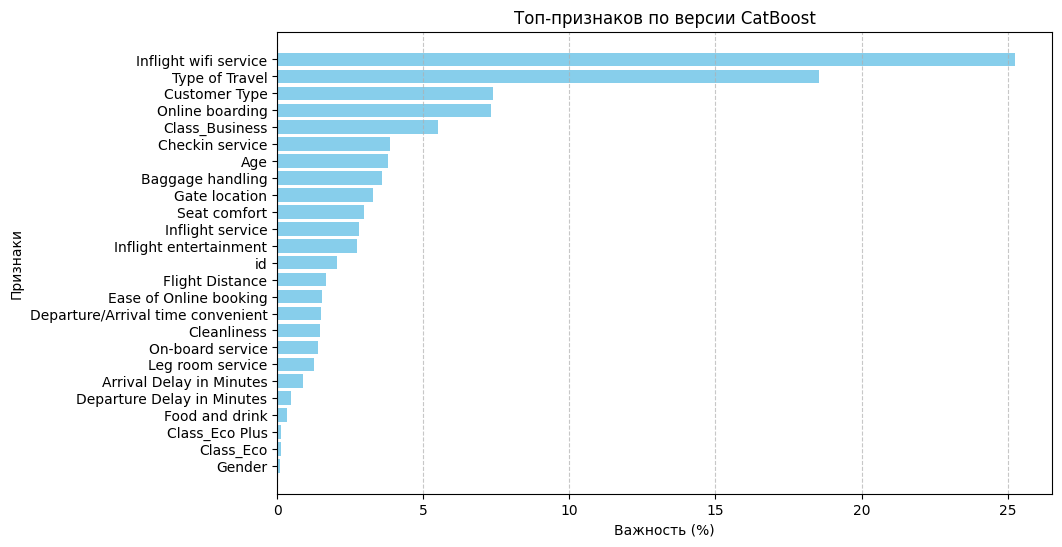

In [63]:
# Задание 6.13

importances = cat_model.get_feature_importance()
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность (%)': importances
}).sort_values(by='Важность (%)', ascending=False)

print("Важность признаков для модели CatBoost:")
print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Признак'][::-1], feature_importance_df['Важность (%)'][::-1], color='skyblue')
plt.xlabel('Важность (%)')
plt.ylabel('Признаки')
plt.title('Топ-признаков по версии CatBoost')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### <center>7.Стэкинг<center>
#### Блэндинг
#### Стекинг

In [64]:
frog_data = pd.read_csv('C:\\IDE\\data\\Block_6\\Frogs_MFCCs.csv')
frog_data.head()

,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22,Family,Genus,Species,RecordID
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038,Leptodactylidae,Adenomera,AdenomeraAndre,1
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056,Leptodactylidae,Adenomera,AdenomeraAndre,1
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162,Leptodactylidae,Adenomera,AdenomeraAndre,1
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954,Leptodactylidae,Adenomera,AdenomeraAndre,1
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244,Leptodactylidae,Adenomera,AdenomeraAndre,1


In [65]:
X = frog_data.drop(['Family', 'Genus', 'Species', 'RecordID'], axis=1)
y = frog_data['Family']

In [70]:
y = y.apply(lambda x: 1 if x == 'Dendrobatidae' else 0)

In [71]:
X.head()

,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_13,MFCCs_14,MFCCs_15,MFCCs_16,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.156436,0.082245,0.135752,-0.024017,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,-0.254341,0.022786,0.163320,0.012022,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,-0.237384,0.050791,0.207338,0.083536,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.317084,-0.011567,0.100413,-0.050224,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,-0.298524,0.037439,0.219153,0.062837,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=31)

In [74]:
# Задание 7.5

rf_model = RandomForestClassifier(n_estimators=10, random_state=42)

rf_model.fit(X_train, y_train)
y_test_pred = rf_model.predict(X_test)
print('F1-score для тестовой выборки: ', round(metrics.f1_score(y_test, y_test_pred),2))

F1-score для тестовой выборки:  0.97


In [76]:
# Задание 7.6

base_models = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=31)),
    ('knn', KNeighborsClassifier(n_neighbors=11)),
    ('nb', GaussianNB())
]

meta_model = LogisticRegression()

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)
y_test_pred = stacking_model.predict(X_test)
print('F1-score для тестовой выборки: ', round(metrics.f1_score(y_test, y_test_pred),2))

F1-score для тестовой выборки:  0.99
